In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ==========================================
# 1. Custom Dataset Loader (Updated for DataFrames)
# ==========================================
class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        # We now pass a DataFrame directly so we can split it beforehand
        self.labels_df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name = str(self.labels_df.iloc[idx]['image'])
        if not img_name.endswith('.jpeg'):
            img_name += '.jpeg'
            
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        label = int(self.labels_df.iloc[idx]['level'])
        return image, label

In [4]:
# ==========================================
# 2. Data Preparation and Splitting
# ==========================================
LABELS_PATH = 'trainLabels.csv' 
IMAGE_DIR = 'train_preprocessed' 

print("Loading and filtering dataset...")
# Load the full CSV
if LABELS_PATH.endswith('.csv'):
    full_df = pd.read_csv(LABELS_PATH)
else:
    full_df = pd.read_excel(LABELS_PATH)

# Filter out images that don't exist in the folder
def check_image_exists(img_name):
    img_str = str(img_name)
    if not img_str.endswith('.jpeg'):
        img_str += '.jpeg'
    return os.path.exists(os.path.join(IMAGE_DIR, img_str))

mask = full_df['image'].apply(check_image_exists)
filtered_df = full_df[mask].reset_index(drop=True)

if len(filtered_df) == 0:
    raise ValueError(f"No matching images found in '{IMAGE_DIR}'. Please check your paths.")

print(f"Found {len(filtered_df)} valid images. Splitting data 70/30...")

# Split the dataframe 70/30. 
# stratify=filtered_df['level'] ensures the ratio of 0-4 classes remains the same in both sets.
train_df, test_df = train_test_split(filtered_df, test_size=0.30, random_state=42, stratify=filtered_df['level'])

Loading and filtering dataset...
Found 8408 valid images. Splitting data 70/30...


In [5]:
# ==========================================
# 3. Transforms and DataLoaders
# ==========================================
# Training gets data augmentation (flips, rotations) to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Testing ONLY gets resized and normalized. No random rotations or flips!
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RetinopathyDataset(dataframe=train_df, image_dir=IMAGE_DIR, transform=train_transform)
test_dataset = RetinopathyDataset(dataframe=test_df, image_dir=IMAGE_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# No need to shuffle test data
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False) 

print(f"Training set: {len(train_dataset)} images")
print(f"Testing set: {len(test_dataset)} images")

Training set: 5885 images
Testing set: 2523 images


In [11]:
from tqdm import tqdm 

## 1. ResNet50

In [5]:
# ==========================================
# 4. Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Using device: cuda


In [6]:
from tqdm import tqdm  # Add this to your imports at the top

# ==========================================
# 5. Training Loop
# ==========================================
num_epochs = 32
train_losses = []
train_accuracies = []

print("\n--- Starting Training ---")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Wrap train_loader with tqdm for a progress bar!
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update the progress bar with the current loss
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * (correct / total)
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    # Exact float numbers and exact correct/total counts
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')


--- Starting Training ---


KeyboardInterrupt: 

In [ ]:
# ==========================================
# 6. Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data ---")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data ---



Overall Test Accuracy: 77.88347205707491% (1965/2523)
Quadratic Weighted Kappa: 0.611507679427868

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1845
           1       0.29      0.08      0.12       177
           2       0.54      0.49      0.51       385
           3       0.64      0.48      0.55        66
           4       0.64      0.36      0.46        50

    accuracy                           0.78      2523
   macro avg       0.59      0.47      0.51      2523
weighted avg       0.74      0.78      0.75      2523


Plots saved as 'training_metrics.png' and 'confusion_matrix.png'


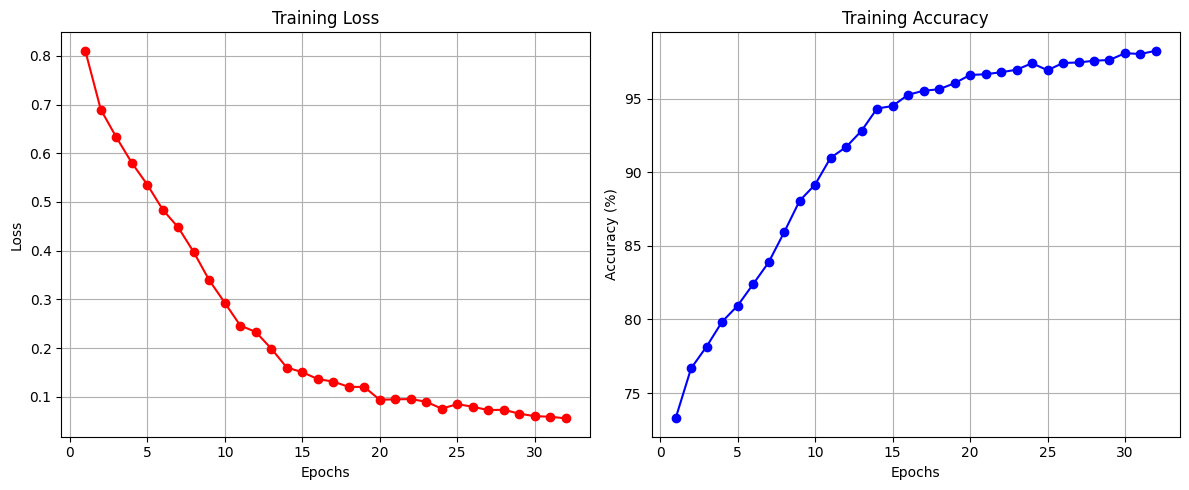

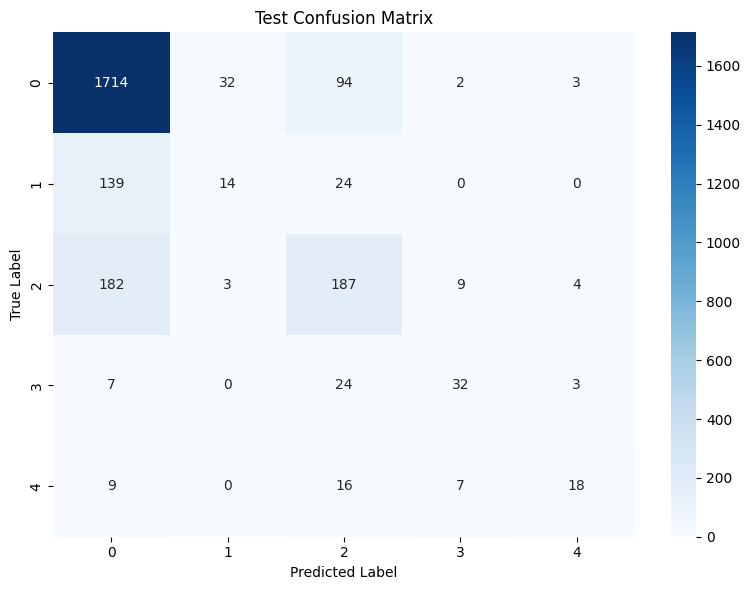

In [ ]:
# ==========================================
# 7. Metrics & Visualization
# ==========================================
# Calculate exact test accuracy
test_correct = sum(1 for p, l in zip(all_preds, all_labels) if p == l)
test_total = len(all_labels)
test_acc = 100 * (test_correct / test_total)

print(f"\nOverall Test Accuracy: {test_acc}% ({test_correct}/{test_total})")

kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')

print("\nPlots saved as 'training_metrics.png' and 'confusion_matrix.png'")
plt.show()

In [ ]:
# ==========================================
# 8.a. Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data ---")
model.eval()
all_preds_x = []
all_labels_x = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_x.extend(predicted.cpu().numpy())
        all_labels_x.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data ---



Overall Training Accuracy: 99.20135938827528% (5838/5885)
Quadratic Weighted Kappa: 0.9899940865039094

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4305
           1       0.99      0.95      0.97       411
           2       0.98      0.99      0.99       898
           3       0.99      0.99      0.99       155
           4       1.00      1.00      1.00       116

    accuracy                           0.99      5885
   macro avg       0.99      0.99      0.99      5885
weighted avg       0.99      0.99      0.99      5885


Plots saved as 'training_metrics.png' and 'confusion_matrix.png'


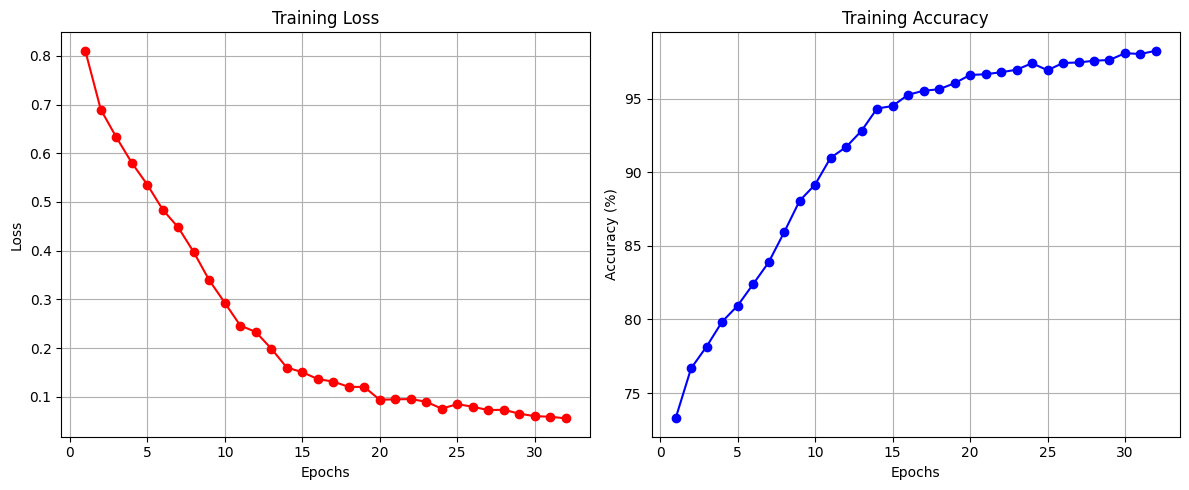

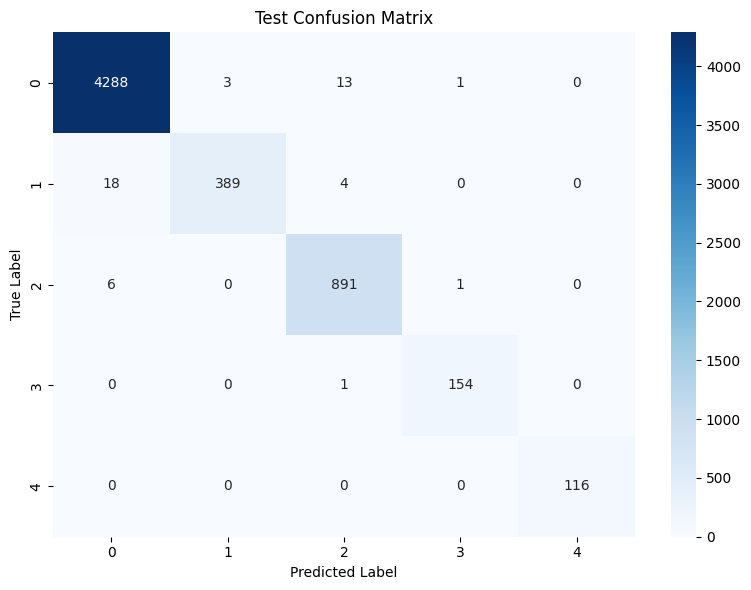

In [ ]:
# ==========================================
# 8. Metrics & Visualization
# ==========================================
# Calculate exact test accuracy
train_correct = sum(1 for p, l in zip(all_preds_x, all_labels_x) if p == l)
train_total = len(all_labels_x)
train_acc = 100 * (train_correct / train_total)

print(f"\nOverall Training Accuracy: {train_acc}% ({train_correct}/{train_total})")

kappa = cohen_kappa_score(all_labels_x, all_preds_x, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa}")

print("\nClassification Report:")
print(classification_report(all_labels_x, all_preds_x, zero_division=0))
# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels_x, all_preds_x)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')

print("\nPlots saved as 'training_metrics.png' and 'confusion_matrix.png'")
plt.show()

## 2. VGG16

In [11]:
# ==========================================
# VGG16 - Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
num_ftrs = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Linear(num_ftrs, 5)
model_vgg16 = model_vgg16.to(device)

criterion_vgg16 = nn.CrossEntropyLoss()
optimizer_vgg16 = torch.optim.Adam(model_vgg16.parameters(), lr=0.0001)

Using device: cuda


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:43<00:00, 12.7MB/s] 


In [12]:
# ==========================================
# VGG16 - Training Loop
# ==========================================
num_epochs = 32
train_losses_vgg16 = []
train_accuracies_vgg16 = []

print("\n--- Starting Training (VGG16) ---")
for epoch in range(num_epochs):
    model_vgg16.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_vgg16(images)
        loss = criterion_vgg16(outputs, labels)
        
        optimizer_vgg16.zero_grad()
        loss.backward()
        optimizer_vgg16.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * (correct / total)
    
    train_losses_vgg16.append(epoch_loss)
    train_accuracies_vgg16.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')


--- Starting Training (VGG16) ---


Epoch [1/32] Completed - Loss: 0.8701846819047047, Accuracy: 73.06711979609176% (4300/5885)


Epoch [2/32] Completed - Loss: 0.7837447323229002, Accuracy: 74.52846219201359% (4386/5885)


Epoch [3/32] Completed - Loss: 0.7480393237960727, Accuracy: 75.36108751062022% (4435/5885)


Epoch [4/32] Completed - Loss: 0.7103593615086182, Accuracy: 76.38062871707731% (4495/5885)


...

Epoch [11/32] Completed - Loss: 0.5406867793720701, Accuracy: 82.48088360237892% (4854/5885)


Epoch [12/32] Completed - Loss: 0.5257829963229597, Accuracy: 83.21155480033985% (4897/5885)


Epoch [13/32] Completed - Loss: 0.5138521948019448, Accuracy: 83.41546304163127% (4909/5885)


Epoch [14/32] Completed - Loss: 0.48059716298366373, Accuracy: 84.29906542056075% (4961/5885)


KeyboardInterrupt: 

In [ ]:
# ==========================================
# VGG16 - Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data (VGG16) ---")
model_vgg16.eval()
all_preds_vgg16 = []
all_labels_vgg16 = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_vgg16(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_vgg16.extend(predicted.cpu().numpy())
        all_labels_vgg16.extend(labels.cpu().numpy())

In [ ]:
# ==========================================
# VGG16 - Metrics & Visualization
# ==========================================
test_correct_vgg16 = sum(1 for p, l in zip(all_preds_vgg16, all_labels_vgg16) if p == l)
test_total_vgg16 = len(all_labels_vgg16)
test_acc_vgg16 = 100 * (test_correct_vgg16 / test_total_vgg16)

print(f"\nOverall Test Accuracy (VGG16): {test_acc_vgg16}% ({test_correct_vgg16}/{test_total_vgg16})")

kappa_vgg16 = cohen_kappa_score(all_labels_vgg16, all_preds_vgg16, weights='quadratic')
print(f"Quadratic Weighted Kappa (VGG16): {kappa_vgg16}")

print("\nClassification Report (VGG16):")
print(classification_report(all_labels_vgg16, all_preds_vgg16, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_vgg16, label='Training Loss', color='green', marker='o')
plt.title('Training Loss (VGG16)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_vgg16, label='Training Accuracy', color='purple', marker='o')
plt.title('Training Accuracy (VGG16)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics_vgg16.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_vgg16 = confusion_matrix(all_labels_vgg16, all_preds_vgg16)
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix (VGG16)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_vgg16.png')

print("\nPlots saved as 'training_metrics_vgg16.png' and 'confusion_matrix_vgg16.png'")
plt.show()

## 3. DenseNet121

In [7]:
# ==========================================
# DenseNet121 - Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
num_ftrs = model_densenet.classifier.in_features
model_densenet.classifier = nn.Linear(num_ftrs, 5)
model_densenet = model_densenet.to(device)

criterion_densenet = nn.CrossEntropyLoss()
optimizer_densenet = torch.optim.Adam(model_densenet.parameters(), lr=0.0001)

Using device: cuda


In [8]:
# ==========================================
# DenseNet121 - Training Loop
# ==========================================
num_epochs = 32
train_losses_densenet = []
train_accuracies_densenet = []

print("\n--- Starting Training (DenseNet121) ---")
for epoch in range(num_epochs):
    model_densenet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_densenet(images)
        loss = criterion_densenet(outputs, labels)
        
        optimizer_densenet.zero_grad()
        loss.backward()
        optimizer_densenet.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * (correct / total)
    
    train_losses_densenet.append(epoch_loss)
    train_accuracies_densenet.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')


--- Starting Training (DenseNet121) ---


Epoch [1/32] Completed - Loss: 0.7875722799774098, Accuracy: 73.9677145284622% (4353/5885)


Epoch [2/32] Completed - Loss: 0.6720915996753003, Accuracy: 76.94137638062871% (4528/5885)


Epoch [3/32] Completed - Loss: 0.6172009753873167, Accuracy: 78.62361937128293% (4627/5885)


Epoch [4/32] Completed - Loss: 0.5776806104847271, Accuracy: 79.9660152931181% (4706/5885)


...

Epoch [28/32] Completed - Loss: 0.06258213142269675, Accuracy: 97.67204757858964% (5748/5885)


Epoch [29/32] Completed - Loss: 0.05891752021441631, Accuracy: 98.06287170773153% (5771/5885)


Epoch [30/32] Completed - Loss: 0.08561589654140256, Accuracy: 96.82242990654206% (5698/5885)


Epoch [31/32] Completed - Loss: 0.07331304617400747, Accuracy: 97.50212404418012% (5738/5885)


Epoch [32/32] Completed - Loss: 0.05229611698988541, Accuracy: 98.23279524214104% (5781/5885)


In [9]:
# ==========================================
# DenseNet121 - Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data (DenseNet121) ---")
model_densenet.eval()
all_preds_densenet = []
all_labels_densenet = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_densenet(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_densenet.extend(predicted.cpu().numpy())
        all_labels_densenet.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data (DenseNet121) ---



Overall Test Accuracy (DenseNet121): 77.84383670233849% (1964/2523)
Quadratic Weighted Kappa (DenseNet121): 0.5650679034566758

Classification Report (DenseNet121):
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1845
           1       0.25      0.04      0.07       177
           2       0.61      0.30      0.40       385
           3       0.56      0.45      0.50        66
           4       0.78      0.36      0.49        50

    accuracy                           0.78      2523
   macro avg       0.60      0.42      0.47      2523
weighted avg       0.73      0.78      0.73      2523


Plots saved as 'training_metrics_densenet121.png' and 'confusion_matrix_densenet121.png'


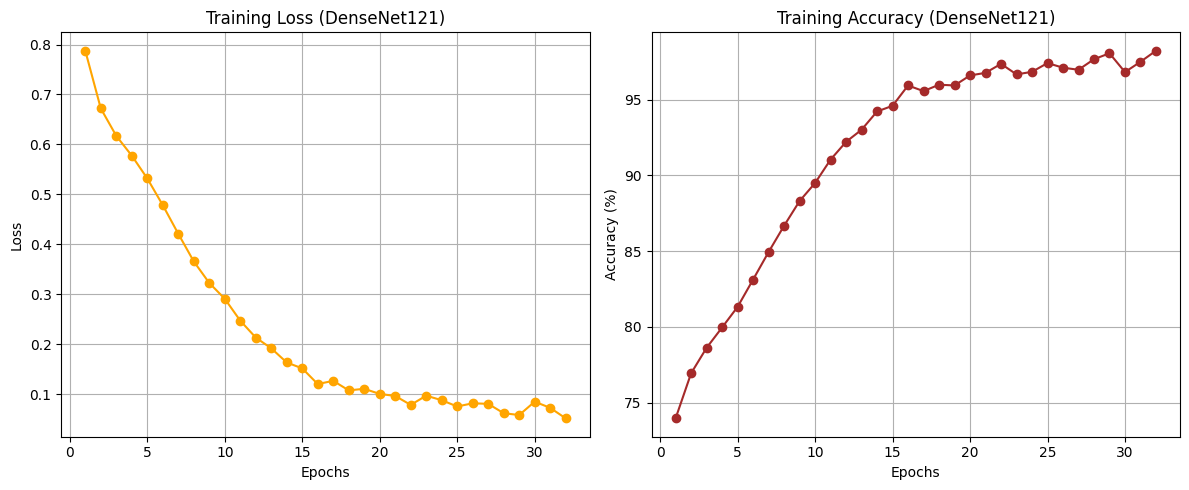

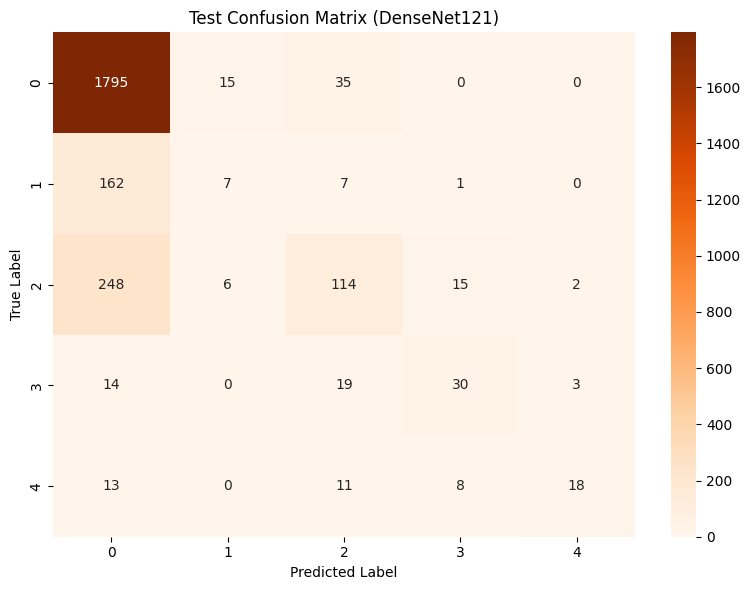

In [10]:
# ==========================================
# DenseNet121 - Metrics & Visualization
# ==========================================
test_correct_densenet = sum(1 for p, l in zip(all_preds_densenet, all_labels_densenet) if p == l)
test_total_densenet = len(all_labels_densenet)
test_acc_densenet = 100 * (test_correct_densenet / test_total_densenet)

print(f"\nOverall Test Accuracy (DenseNet121): {test_acc_densenet}% ({test_correct_densenet}/{test_total_densenet})")

kappa_densenet = cohen_kappa_score(all_labels_densenet, all_preds_densenet, weights='quadratic')
print(f"Quadratic Weighted Kappa (DenseNet121): {kappa_densenet}")

print("\nClassification Report (DenseNet121):")
print(classification_report(all_labels_densenet, all_preds_densenet, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_densenet, label='Training Loss', color='orange', marker='o')
plt.title('Training Loss (DenseNet121)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_densenet, label='Training Accuracy', color='brown', marker='o')
plt.title('Training Accuracy (DenseNet121)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics_densenet121.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_densenet = confusion_matrix(all_labels_densenet, all_preds_densenet)
sns.heatmap(cm_densenet, annot=True, fmt='d', cmap='Oranges', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix (DenseNet121)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_densenet121.png')

print("\nPlots saved as 'training_metrics_densenet121.png' and 'confusion_matrix_densenet121.png'")
plt.show()

## 4. EfficientNet-B2

In [11]:
# ==========================================
# EfficientNet-B2 - Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_efficientnet = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
num_ftrs = model_efficientnet.classifier[1].in_features
model_efficientnet.classifier[1] = nn.Linear(num_ftrs, 5)
model_efficientnet = model_efficientnet.to(device)

criterion_efficientnet = nn.CrossEntropyLoss()
optimizer_efficientnet = torch.optim.Adam(model_efficientnet.parameters(), lr=0.0001)

Using device: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:03<00:00, 9.63MB/s]


In [12]:
# ==========================================
# EfficientNet-B2 - Training Loop
# ==========================================
num_epochs = 32
train_losses_efficientnet = []
train_accuracies_efficientnet = []

print("\n--- Starting Training (EfficientNet-B2) ---")
for epoch in range(num_epochs):
    model_efficientnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_efficientnet(images)
        loss = criterion_efficientnet(outputs, labels)
        
        optimizer_efficientnet.zero_grad()
        loss.backward()
        optimizer_efficientnet.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * (correct / total)
    
    train_losses_efficientnet.append(epoch_loss)
    train_accuracies_efficientnet.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')


--- Starting Training (EfficientNet-B2) ---


Epoch [1/32] Completed - Loss: 0.8338911848385697, Accuracy: 72.93118096856415% (4292/5885)


Epoch [2/32] Completed - Loss: 0.6865566049742958, Accuracy: 76.63551401869158% (4510/5885)


Epoch [3/32] Completed - Loss: 0.6257789808770885, Accuracy: 78.55564995751911% (4623/5885)


Epoch [4/32] Completed - Loss: 0.5701239758130648, Accuracy: 79.32030586236193% (4668/5885)


...

Epoch [28/32] Completed - Loss: 0.05294797785656714, Accuracy: 98.3517417162277% (5788/5885)


Epoch [29/32] Completed - Loss: 0.05378809217172207, Accuracy: 98.18181818181819% (5778/5885)


Epoch [30/32] Completed - Loss: 0.04573703283906228, Accuracy: 98.53865760407817% (5799/5885)


Epoch [31/32] Completed - Loss: 0.041867648123867264, Accuracy: 98.55564995751912% (5800/5885)


Epoch [32/32] Completed - Loss: 0.053304771696038304, Accuracy: 98.11384876805438% (5774/5885)


In [13]:
# ==========================================
# EfficientNet-B2 - Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data (EfficientNet-B2) ---")
model_efficientnet.eval()
all_preds_efficientnet = []
all_labels_efficientnet = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_efficientnet(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_efficientnet.extend(predicted.cpu().numpy())
        all_labels_efficientnet.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data (EfficientNet-B2) ---



Overall Test Accuracy (EfficientNet-B2): 75.94133967499009% (1916/2523)
Quadratic Weighted Kappa (EfficientNet-B2): 0.6002330001930807

Classification Report (EfficientNet-B2):
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1845
           1       0.14      0.09      0.11       177
           2       0.59      0.34      0.43       385
           3       0.53      0.45      0.49        66
           4       0.63      0.44      0.52        50

    accuracy                           0.76      2523
   macro avg       0.54      0.45      0.48      2523
weighted avg       0.73      0.76      0.73      2523


Plots saved as 'training_metrics_efficientnet_b2.png' and 'confusion_matrix_efficientnet_b2.png'


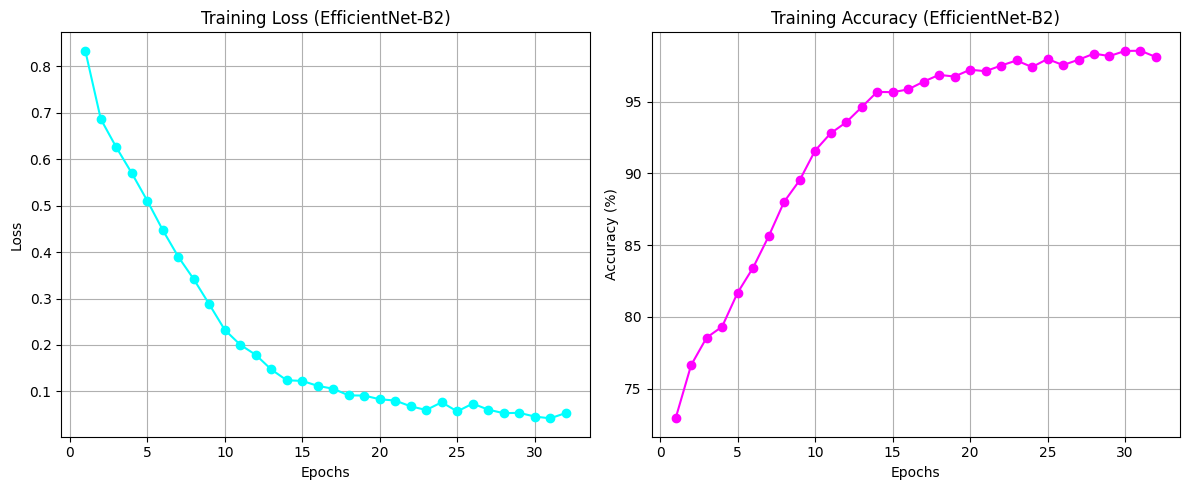

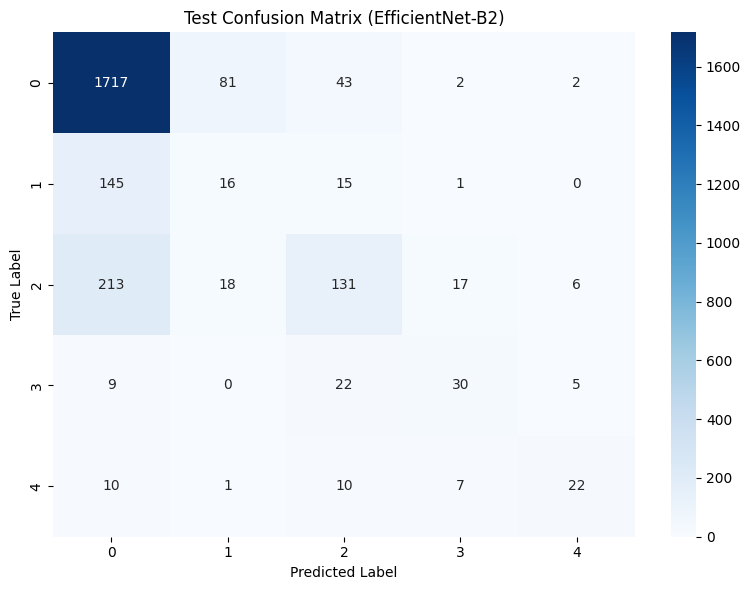

In [14]:
# ==========================================
# EfficientNet-B2 - Metrics & Visualization
# ==========================================
test_correct_efficientnet = sum(1 for p, l in zip(all_preds_efficientnet, all_labels_efficientnet) if p == l)
test_total_efficientnet = len(all_labels_efficientnet)
test_acc_efficientnet = 100 * (test_correct_efficientnet / test_total_efficientnet)

print(f"\nOverall Test Accuracy (EfficientNet-B2): {test_acc_efficientnet}% ({test_correct_efficientnet}/{test_total_efficientnet})")

kappa_efficientnet = cohen_kappa_score(all_labels_efficientnet, all_preds_efficientnet, weights='quadratic')
print(f"Quadratic Weighted Kappa (EfficientNet-B2): {kappa_efficientnet}")

print("\nClassification Report (EfficientNet-B2):")
print(classification_report(all_labels_efficientnet, all_preds_efficientnet, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_efficientnet, label='Training Loss', color='cyan', marker='o')
plt.title('Training Loss (EfficientNet-B2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_efficientnet, label='Training Accuracy', color='magenta', marker='o')
plt.title('Training Accuracy (EfficientNet-B2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics_efficientnet_b2.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_efficientnet = confusion_matrix(all_labels_efficientnet, all_preds_efficientnet)
sns.heatmap(cm_efficientnet, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix (EfficientNet-B2)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_efficientnet_b2.png')

print("\nPlots saved as 'training_metrics_efficientnet_b2.png' and 'confusion_matrix_efficientnet_b2.png'")
plt.show()

## 5. MobileNetV2

In [12]:
# ==========================================
# MobileNetV2 - Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_mobilenetv2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
num_ftrs = model_mobilenetv2.classifier[1].in_features
model_mobilenetv2.classifier[1] = nn.Linear(num_ftrs, 5)
model_mobilenetv2 = model_mobilenetv2.to(device)

criterion_mobilenetv2 = nn.CrossEntropyLoss()
optimizer_mobilenetv2 = torch.optim.Adam(model_mobilenetv2.parameters(), lr=0.0001)

Using device: cuda


In [13]:
# ==========================================
# MobileNetV2 - Training Loop
# ==========================================
num_epochs = 32
train_losses_mobilenetv2 = []
train_accuracies_mobilenetv2 = []

print("\n--- Starting Training (MobileNetV2) ---")
for epoch in range(num_epochs):
    model_mobilenetv2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_mobilenetv2(images)
        loss = criterion_mobilenetv2(outputs, labels)
        
        optimizer_mobilenetv2.zero_grad()
        loss.backward()
        optimizer_mobilenetv2.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * (correct / total)
    
    train_losses_mobilenetv2.append(epoch_loss)
    train_accuracies_mobilenetv2.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')


--- Starting Training (MobileNetV2) ---


Epoch 1/32:   0%|          | 0/368 [00:00<?, ?it/s]

Epoch [1/32] Completed - Loss: 0.8551804522943237, Accuracy: 72.47238742565845% (4265/5885)


Epoch [2/32] Completed - Loss: 0.7272406295751748, Accuracy: 75.22514868309261% (4427/5885)


Epoch [3/32] Completed - Loss: 0.6805080720830871, Accuracy: 76.14273576890399% (4481/5885)


...

Epoch [28/32] Completed - Loss: 0.09586093199196392, Accuracy: 96.6355140186916% (5687/5885)


Epoch [29/32] Completed - Loss: 0.09894828745619515, Accuracy: 96.51656754460492% (5680/5885)


Epoch [30/32] Completed - Loss: 0.09959116320153596, Accuracy: 96.34664401019542% (5670/5885)


Epoch [31/32] Completed - Loss: 0.09707247875390433, Accuracy: 96.65250637213254% (5688/5885)


Epoch [32/32] Completed - Loss: 0.0797908617615062, Accuracy: 97.4001699235344% (5732/5885)


In [14]:
# ==========================================
# MobileNetV2 - Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data (MobileNetV2) ---")
model_mobilenetv2.eval()
all_preds_mobilenetv2 = []
all_labels_mobilenetv2 = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_mobilenetv2(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_mobilenetv2.extend(predicted.cpu().numpy())
        all_labels_mobilenetv2.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data (MobileNetV2) ---



Overall Test Accuracy (MobileNetV2): 75.50535077288941% (1905/2523)
Quadratic Weighted Kappa (MobileNetV2): 0.5485164829446073

Classification Report (MobileNetV2):
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1845
           1       0.14      0.03      0.05       177
           2       0.48      0.40      0.44       385
           3       0.58      0.29      0.38        66
           4       0.50      0.38      0.43        50

    accuracy                           0.76      2523
   macro avg       0.50      0.41      0.44      2523
weighted avg       0.71      0.76      0.72      2523


Plots saved as 'training_metrics_mobilenetv2.png' and 'confusion_matrix_mobilenetv2.png'


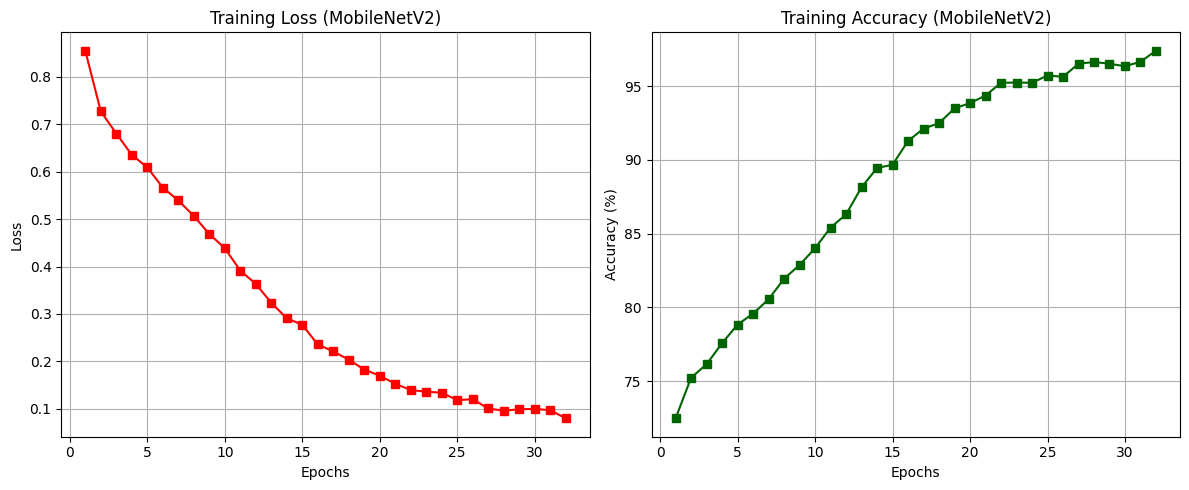

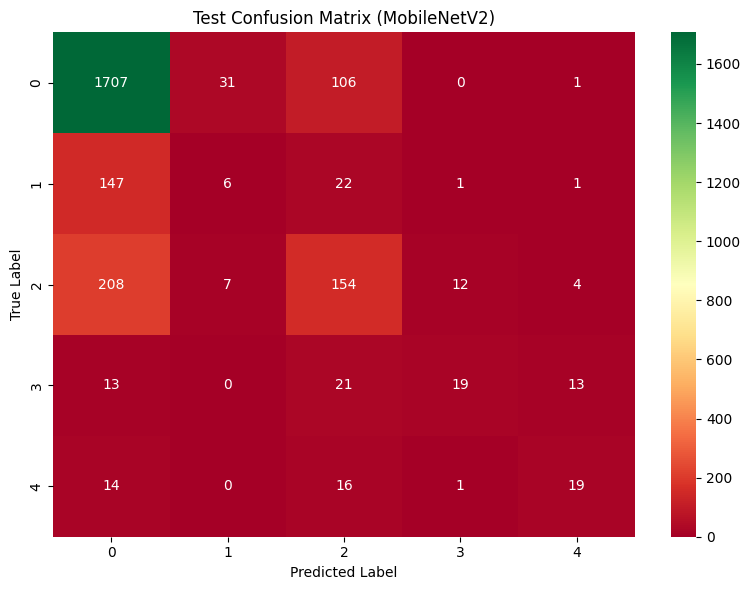

In [15]:
# ==========================================
# MobileNetV2 - Metrics & Visualization
# ==========================================
test_correct_mobilenetv2 = sum(1 for p, l in zip(all_preds_mobilenetv2, all_labels_mobilenetv2) if p == l)
test_total_mobilenetv2 = len(all_labels_mobilenetv2)
test_acc_mobilenetv2 = 100 * (test_correct_mobilenetv2 / test_total_mobilenetv2)

print(f"\nOverall Test Accuracy (MobileNetV2): {test_acc_mobilenetv2}% ({test_correct_mobilenetv2}/{test_total_mobilenetv2})")

kappa_mobilenetv2 = cohen_kappa_score(all_labels_mobilenetv2, all_preds_mobilenetv2, weights='quadratic')
print(f"Quadratic Weighted Kappa (MobileNetV2): {kappa_mobilenetv2}")

print("\nClassification Report (MobileNetV2):")
print(classification_report(all_labels_mobilenetv2, all_preds_mobilenetv2, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_mobilenetv2, label='Training Loss', color='red', marker='s')
plt.title('Training Loss (MobileNetV2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_mobilenetv2, label='Training Accuracy', color='darkgreen', marker='s')
plt.title('Training Accuracy (MobileNetV2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics_mobilenetv2.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_mobilenetv2 = confusion_matrix(all_labels_mobilenetv2, all_preds_mobilenetv2)
sns.heatmap(cm_mobilenetv2, annot=True, fmt='d', cmap='RdYlGn', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix (MobileNetV2)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_mobilenetv2.png')

print("\nPlots saved as 'training_metrics_mobilenetv2.png' and 'confusion_matrix_mobilenetv2.png'")
plt.show()

## 6. Inception V3

In [16]:
# ==========================================
# Inception V3 - Custom Transforms (requires 299x299 input)
# ==========================================
train_transform_inception = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform_inception = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_inception = RetinopathyDataset(dataframe=train_df, image_dir=IMAGE_DIR, transform=train_transform_inception)
test_dataset_inception = RetinopathyDataset(dataframe=test_df, image_dir=IMAGE_DIR, transform=test_transform_inception)

train_loader_inception = DataLoader(train_dataset_inception, batch_size=16, shuffle=True)
test_loader_inception = DataLoader(test_dataset_inception, batch_size=16, shuffle=False)

# ==========================================
# Inception V3 - Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
num_ftrs = model_inception.fc.in_features
model_inception.fc = nn.Linear(num_ftrs, 5)
model_inception = model_inception.to(device)

criterion_inception = nn.CrossEntropyLoss()
optimizer_inception = torch.optim.Adam(model_inception.parameters(), lr=0.0001)

Using device: cuda


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 57.7MB/s] 


In [18]:
# ==========================================
# Inception V3 - Training Loop
# ==========================================
# Disable auxiliary outputs for simpler training
model_inception.aux_logits = False

num_epochs = 32
train_losses_inception = []
train_accuracies_inception = []

print("\n--- Starting Training (Inception V3) ---")
for epoch in range(num_epochs):
    model_inception.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader_inception, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_inception(images)
        loss = criterion_inception(outputs, labels)
        
        optimizer_inception.zero_grad()
        loss.backward()
        optimizer_inception.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader_inception)
    epoch_acc = 100 * (correct / total)
    
    train_losses_inception.append(epoch_loss)
    train_accuracies_inception.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')



--- Starting Training (Inception V3) ---


Epoch [1/32] Completed - Loss: 0.8109648860181156, Accuracy: 73.28802039082413% (4313/5885)


Epoch [2/32] Completed - Loss: 0.6903275486243807, Accuracy: 76.63551401869158% (4510/5885)


Epoch [3/32] Completed - Loss: 0.6250240811268273, Accuracy: 78.67459643160578% (4630/5885)


Epoch [4/32] Completed - Loss: 0.5725994604923155, Accuracy: 80.22090059473237% (4721/5885)


...

Epoch [28/32] Completed - Loss: 0.07299012845633905, Accuracy: 97.50212404418012% (5738/5885)


Epoch [29/32] Completed - Loss: 0.0661289315179127, Accuracy: 97.70603228547154% (5750/5885)


Epoch [30/32] Completed - Loss: 0.0777974165680264, Accuracy: 97.38317757009347% (5731/5885)


Epoch [31/32] Completed - Loss: 0.07541990708926713, Accuracy: 97.57009345794393% (5742/5885)


Epoch [32/32] Completed - Loss: 0.06492450295500811, Accuracy: 97.55310110450297% (5741/5885)


In [19]:
# ==========================================
# Inception V3 - Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data (Inception V3) ---")
model_inception.eval()
all_preds_inception = []
all_labels_inception = []

with torch.no_grad():
    for images, labels in test_loader_inception:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_inception(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_inception.extend(predicted.cpu().numpy())
        all_labels_inception.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data (Inception V3) ---



Overall Test Accuracy (Inception V3): 78.12128418549345% (1971/2523)
Quadratic Weighted Kappa (Inception V3): 0.5963288588132012

Classification Report (Inception V3):
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1845
           1       0.16      0.03      0.06       177
           2       0.62      0.35      0.45       385
           3       0.63      0.33      0.44        66
           4       0.66      0.42      0.51        50

    accuracy                           0.78      2523
   macro avg       0.57      0.42      0.47      2523
weighted avg       0.73      0.78      0.74      2523


Plots saved as 'training_metrics_inception_v3.png' and 'confusion_matrix_inception_v3.png'


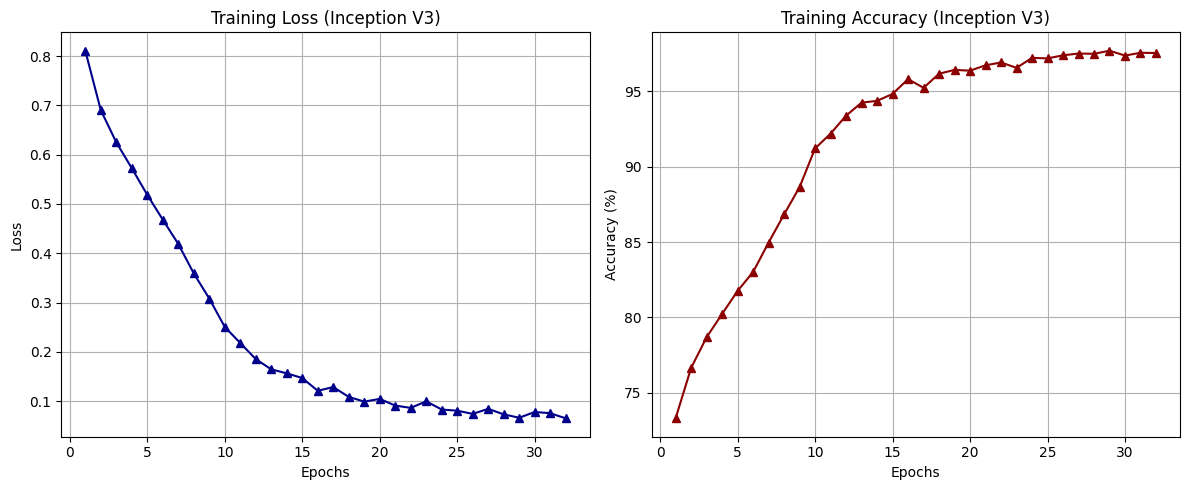

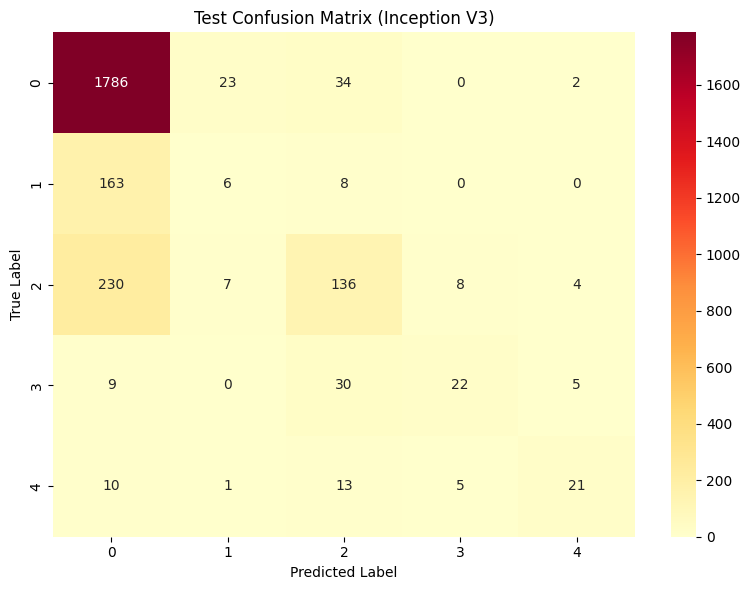

In [20]:
# ==========================================
# Inception V3 - Metrics & Visualization
# ==========================================
test_correct_inception = sum(1 for p, l in zip(all_preds_inception, all_labels_inception) if p == l)
test_total_inception = len(all_labels_inception)
test_acc_inception = 100 * (test_correct_inception / test_total_inception)

print(f"\nOverall Test Accuracy (Inception V3): {test_acc_inception}% ({test_correct_inception}/{test_total_inception})")

kappa_inception = cohen_kappa_score(all_labels_inception, all_preds_inception, weights='quadratic')
print(f"Quadratic Weighted Kappa (Inception V3): {kappa_inception}")

print("\nClassification Report (Inception V3):")
print(classification_report(all_labels_inception, all_preds_inception, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_inception, label='Training Loss', color='darkblue', marker='^')
plt.title('Training Loss (Inception V3)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_inception, label='Training Accuracy', color='darkred', marker='^')
plt.title('Training Accuracy (Inception V3)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics_inception_v3.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_inception = confusion_matrix(all_labels_inception, all_preds_inception)
sns.heatmap(cm_inception, annot=True, fmt='d', cmap='YlOrRd', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix (Inception V3)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_inception_v3.png')

print("\nPlots saved as 'training_metrics_inception_v3.png' and 'confusion_matrix_inception_v3.png'")
plt.show()

## Comparison of All Models

In [21]:
# ==========================================
# Model Comparison Summary
# ==========================================
print("=" * 70)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 70)

comparison_data = {
    'Model': ['DenseNet121', 'EfficientNet-B2', 'MobileNetV2', 'Inception V3'],
    'Test Accuracy (%)': [test_acc_densenet, test_acc_efficientnet, test_acc_mobilenetv2, test_acc_inception],
    'Quadratic Kappa': [kappa_densenet, kappa_efficientnet, kappa_mobilenetv2, kappa_inception]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))
print("\n" + "=" * 70)

# Create a comprehensive comparison plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Test Accuracies
models = comparison_df['Model']
accuracies = comparison_df['Test Accuracy (%)']
colors_bar = ['green', 'orange', 'cyan', 'purple']
bars1 = axes[0].bar(models, accuracies, color=colors_bar, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# Plot 2: Quadratic Kappa Scores
kappas = comparison_df['Quadratic Kappa']
bars2 = axes[1].bar(models, kappas, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Quadratic Weighted Kappa', fontsize=12)
axes[1].set_title('Quadratic Weighted Kappa Comparison', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=300, bbox_inches='tight')
print("\nComparison plot saved as 'models_comparison.png'")
plt.show()

# Find best model
best_model_idx = comparison_df['Test Accuracy (%)'].idxmax()
print(f"\n🏆 BEST MODEL: {comparison_df.loc[best_model_idx, 'Model']} with {comparison_df.loc[best_model_idx, 'Test Accuracy (%)']:.2f}% accuracy")

COMPREHENSIVE MODEL COMPARISON


NameError: name 'test_acc_densenet' is not defined